# Análisis Exploratorio de Datos (EDA)
Los datos ya han sido ingeridos y procesados para su análisis. En este notebook, se prentenden contestar las siguientes preguntas relacionadas al contenido de los mensajes del grupo personal seleccionado: 

* __1. ¿Cuál es el usuario que más mensajes envía?__
* __2.¿Cual es la frecuencia promedio de palabras por mensaje de texto de cada usuario?__
* __3.¿Cuál es el usuario que más palabras envía? ¿Y el que envía más *stickers*?__
* __4.¿Que días de la semana se mandan más mensajes y cuales menos? ¿Hay un patron semanal? ¿Y por hora del día?__
* __5.¿Que palabras son las más usadas por cada usuario? ¿Y en general? ¿Que palabras son las más usadas en el grupo que no sean *stop words*?__
* __6.¿Cuales son los adjetivos más usados?__
* __7.¿Qué usuario es el que envia los textos más largos? ¿Y los más cortos?__



In [148]:
# Importar librerias 
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Definir la ruta donde se encuentra el archivo .csv
ruta = os.path.join('..', 'data', 'processed', 'datos_procesados.csv')

# Definir dataframe con parse_dates['timestamp'] para que la columna timestamp tenga formato
df = pd.read_csv(ruta, index_col=0, parse_dates=['timestamp'])

# Verificar dtypes
#df['year'] = df['timestamp'].dt.year
print(df.dtypes)

df.head()

timestamp         datetime64[us]
personaje                    str
contenido                    str
tipo_contenido               str
dtype: object


,timestamp,personaje,contenido,tipo_contenido
0,2024-05-24 11:27:00,Shrek,Cambié de cel y se me borraron todos los datos...,texto
1,2024-05-24 11:27:00,Shrek,‎STK-20240524-WA0002.webp (archivo adjunto),sticker
2,2024-05-24 11:31:00,Lord Farquad,We que chilo alv,texto
3,2024-05-24 11:31:00,Shrek,Y si,texto
4,2024-05-24 11:31:00,Lord Farquad,La quisieras,texto


### __1. ¿Cuál es el usuario que más mensajes envía?__

In [149]:
# Guardar una copia del df original
df_pregunta1 = df.copy()

# Crear una columna con el año
df_pregunta1['year'] = df['timestamp'].dt.year

# Agrupar los datos por personaje y año y contar el numero de mensajes que tiene cada unuo
df_pregunta1 = df_pregunta1.groupby(['personaje','year'])['contenido'].count().reset_index(name='Numero de Mensajes')

# Ordenar por numero de mensajes
df_pregunta1.sort_values(by='Numero de Mensajes', inplace=True)
df_pregunta1.head()

,personaje,year,Numero de Mensajes
8,Lobo de Sexo Dudoso,2026,267
6,Lobo de Sexo Dudoso,2024,756
7,Lobo de Sexo Dudoso,2025,888
5,Fiona,2026,2523
2,Burro,2026,3660


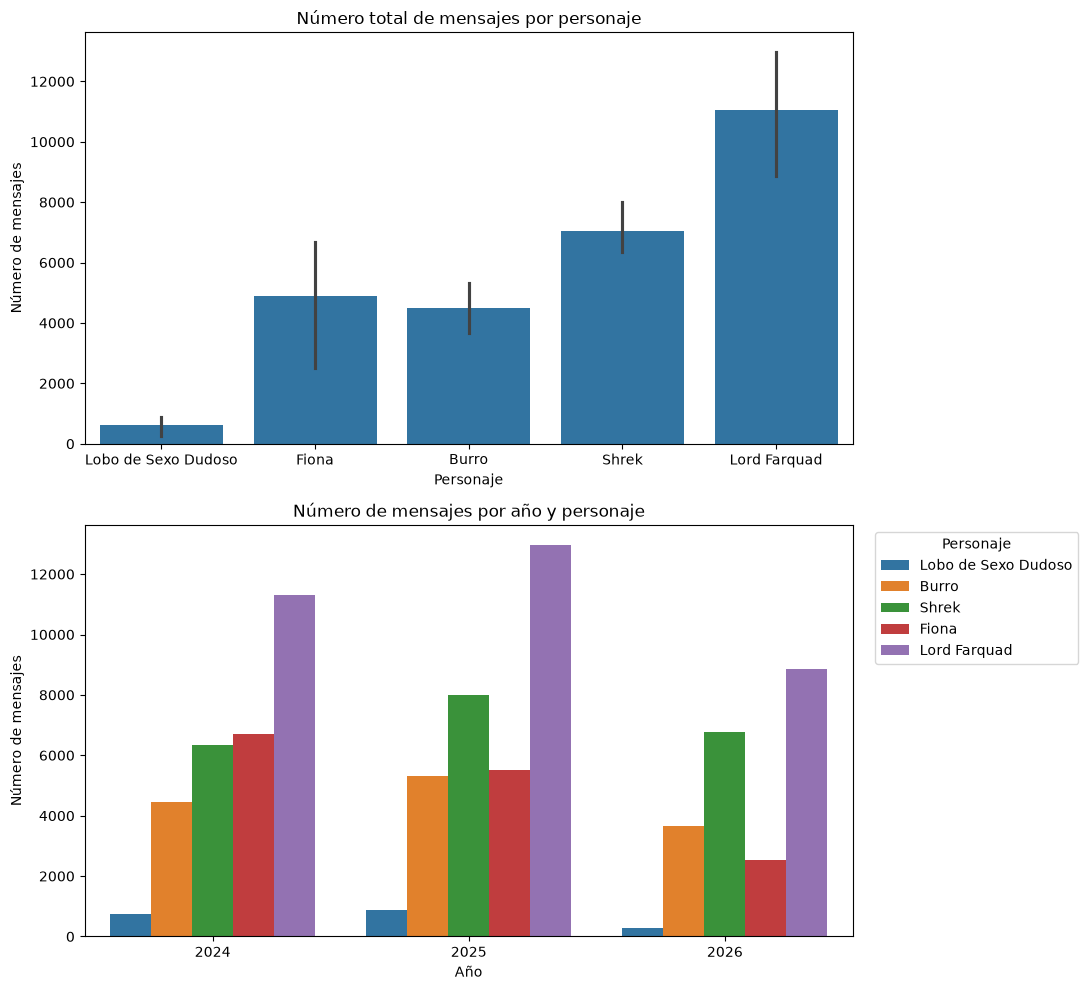

In [150]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definir una sola figura con 2 subplots verticales 
fig, ax = plt.subplots(2, 1, figsize=(11, 10))

# Gráfoca 1: Total de mensajes por personaje de todos los años
sns.barplot(data=df_pregunta1, x="personaje", y="Numero de Mensajes", ax=ax[0])
ax[0].set_title("Número total de mensajes por personaje", fontsize=12)
ax[0].set_xlabel("Personaje")
ax[0].set_ylabel("Número de mensajes")
ax[0].tick_params(axis="x")

# Gráfica 2: mensajes de cada personaje por año
sns.barplot(data=df_pregunta1, x="year", y="Numero de Mensajes", hue="personaje",ax=ax[1], )
ax[1].set_title("Número de mensajes por año y personaje", fontsize=12)
ax[1].set_xlabel("Año")
ax[1].set_ylabel("Número de mensajes")

# Mover la leyenda afuera de la gráfica (a la derecha) para que no tape las barras
sns.move_legend(ax[1], "upper left", bbox_to_anchor=(1.02, 1), title="Personaje")

# Ajustar espaciado entre subplots para evitar superposiciones
plt.tight_layout()
plt.show()

El usuario que más mensajes ha enviado en todos los años ha sido Lord Farquad. 

### __2.¿Cual es la frecuencia promedio de palabras por mensaje de texto de cada usuario?__

C:\Users\victo\AppData\Local\Temp\ipykernel_30060\564523622.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


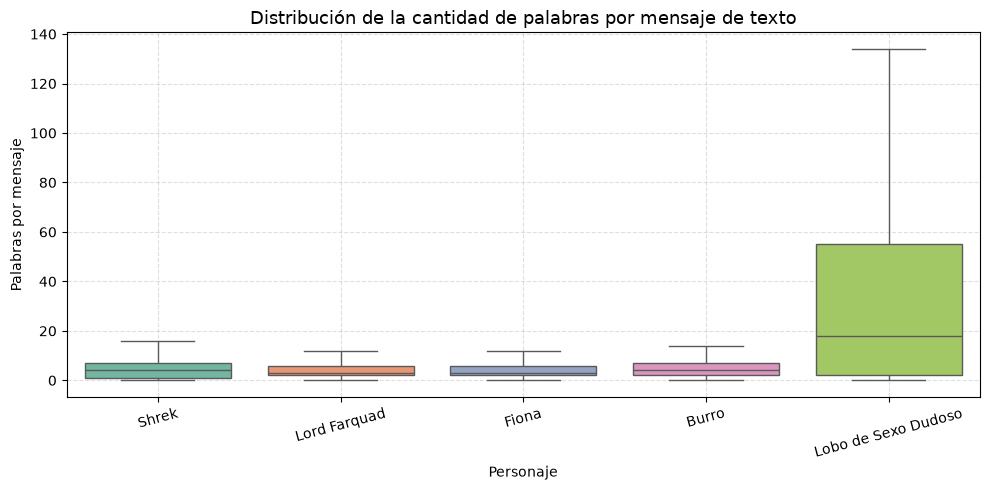

In [162]:
# Importar libreria re para trabajar con expresioner regulares
import re

# Filtrar el df por el tipo de contenido que solo es texto y guardar una dopia en df_texto
df_texto = df[df["tipo_contenido"] == "texto"].copy()

# Crear funcion para contar el numero de palabras dentro de cada mensaje
def conteo_palabras(mensajes):

    # Asegurar que solo se este trabajando con strings
    if not isinstance(mensajes, str):
        return 0
    # Uso de una expresion regular que pueda exxtraer todas las secuencias de palabras
    palabras = re.findall(r"\b[a-záéíóúüñA-ZÁÉÍÓÚÜÑ0-9]+\b", mensajes)
    return len(palabras)

# Aplicar la funcion conteo_palabras al df_texto e incluir una nueva columna que contenga el numero de palabras por por mensaje
df_texto['frecuencia_palabras'] = df_texto['contenido'].apply(conteo_palabras)

fig, ax = plt.subplots(figsize=(10, 5))

# Graficar la distribución usando df_texto
sns.boxplot(
    data=df_texto,
    x="personaje",
    y="frecuencia_palabras",
    palette="Set2",
    showfliers=False,  # Oculta los outliers extremos para que la caja no quede aplastada
    ax=ax,
)

ax.set_title(
    "Distribución de la cantidad de palabras por mensaje de texto", fontsize=13
)
ax.set_xlabel("Personaje")
ax.set_ylabel("Palabras por mensaje")
ax.tick_params(axis="x", rotation=15)
ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

,personaje,mean,median,count
0,Burro,5.281377,4.0,12812
1,Fiona,4.399480,3.0,14226
2,Lobo de Sexo Dudoso,40.106806,18.0,1910
3,Lord Farquad,4.724257,3.0,32436
4,Shrek,5.231581,4.0,20088


In [144]:

import re
from collections import Counter


# Crear una serie que solo contenga los mensajes enviados en el historial
contenido = df['contenido']

# Generar un solo texto enorme en un solo renglon de la serie contenido 
texto_completo = " ".join(df["contenido"].dropna().astype(str)).lower()

# Extraer palabras ignorando puntuación, comas o signos raros con re.findall. 
# la expresion regular "\b[a-záéíóúüñ]+\b buscara mas de un caracter de la a a la z e incluira signos con acentos
# re.findall devuelve una lista con todas las palabras dentro del texto
palabras = re.findall(r"\b[a-záéíóúüñ]+\b", texto_completo)


# Filtrar las stopwords dentro de la lista palabras usando el modulo stopwords de la libria nltk.corpus
import nltk
from nltk.corpus import stopwords
nltk.download("stopwords") # Descarga las stopwords
stopwords_es = set(stopwords.words("spanish")) # obtener elementos unicos en español 

palabras_limpias = []
lista_nombres = ['shrek', 'fiona', 'burro', 'lord', 'farquad', 'lobo', 'de', 'sexo', 'dudoso']
for p in palabras:
    if (p not in stopwords_es) and (len(p) > 2) and (p not in lista_nombres): # Evaluamos que la palabra actual no se encuentra en stopwords
        palabras_limpias.append(p)

# Contar las palabras limpias utilizando la funcion Counter del modulo collections
conteo_palabras = Counter(palabras_limpias)


# Generar un datadrame con las palabras limpias obtenidas
df_palabras = pd.DataFrame(conteo_palabras.items(), columns=["Palabra", "Frecuencia"])
df_palabras.sort_values(by='Frecuencia', ascending=False, inplace=True)
df_palabras.head(20)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\victo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Palabra,Frecuencia
1868,multimedia,4818
1869,omitido,4818
7,archivo,3123
8,adjunto,3120
5,stk,1933
6,webp,1915
10,alv,1311
46,bien,1174
89,verga,1161
59,https,1155
